                                              FRAUD DETECTION PROJECT

STEP-1 LOADING DATASET

In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Asus\Downloads\Project\FraudDetectionDataset.csv")
df.shape #exact dataset shape

(51000, 12)

                                             EXPLORATORY DATA ANALYSIS(EDA)

SEE ALL COLUMN NAMES

In [3]:
print(df.columns.tolist())

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


DATATYPES AND NON-NULL COUNTS

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

ROWS

In [5]:
df.head(10)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
5,T6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0
6,T7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1
7,T8,4092,635.75,ATM Withdrawal,13.0,Tablet,Boston,2,13,10,Debit Card,0
8,T9,2638,2318.87,Bank Transfer,NaN,Mobile,San Francisco,4,110,12,Debit Card,0
9,T10,3169,3656.17,Bill Payment,3.0,Mobile,Chicago,4,66,3,Net Banking,0


BASIC STATISTICS

In [6]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


LOOKING FOR FRAUD COLUMN

In [7]:
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values → {df[col].unique()[:5]}")
df["Fraudulent"].value_counts()

Transaction_ID: 50000 unique values → ['T1' 'T2' 'T3' 'T4' 'T5']
User_ID: 4000 unique values → [4174 4507 1860 2294 2130]
Transaction_Amount: 44821 unique values → [1292.76 1554.58 2395.02  100.1  1490.5 ]
Transaction_Type: 5 unique values → ['ATM Withdrawal' 'Bill Payment' 'POS Payment' 'Bank Transfer'
 'Online Purchase']
Time_of_Transaction: 24 unique values → [16. 13. nan 15. 19.]
Device_Used: 4 unique values → ['Tablet' 'Mobile' 'Desktop' nan 'Unknown Device']
Location: 8 unique values → ['San Francisco' 'New York' nan 'Chicago' 'Boston']
Previous_Fraudulent_Transactions: 5 unique values → [0 4 3 2 1]
Account_Age: 119 unique values → [119  79 115   3  57]
Number_of_Transactions_Last_24H: 14 unique values → [13  3  9  4  7]
Payment_Method: 5 unique values → ['Debit Card' 'Credit Card' nan 'UPI' 'Net Banking']
Fraudulent: 2 unique values → [0 1]


Fraudulent
0    48490
1     2510
Name: count, dtype: int64

                                             DATA PREPROCESSING             

DROP UNNECESSARY COLUMNS

In [8]:
# Reload fresh data first
df = pd.read_csv(r"C:\Users\Asus\Downloads\Project\FraudDetectionDataset.csv")
print(f"✅ Data reloaded: {df.shape}")

# Now drop Transaction_ID
df.drop(columns=['Transaction_ID'], inplace=True)
print(f"✅ Transaction_ID dropped")
print(f"Shape now : {df.shape}")
print(f"Columns   : {df.columns.tolist()}")

✅ Data reloaded: (51000, 12)
✅ Transaction_ID dropped
Shape now : (51000, 11)
Columns   : ['User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


HANDLE MISSING VALUES

In [9]:
# First check missing values count
print(df.isnull().sum())

User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


FIX MISSING VALUES

In [10]:
# NUMERIC columns → fill empty cells with MEDIAN value
# Median = middle value of all numbers (not affected by outliers)
df['Transaction_Amount'].fillna(df['Transaction_Amount'].median(), inplace=True)
df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median(), inplace=True)

# CATEGORICAL columns → fill empty cells with MODE value  
# Mode = most frequently appearing value
df['Device_Used'].fillna(df['Device_Used'].mode()[0], inplace=True)
df['Location'].fillna(df['Location'].mode()[0], inplace=True)
df['Payment_Method'].fillna(df['Payment_Method'].mode()[0], inplace=True)

# Verify all missing values are fixed
print("Missing values remaining:")
print(df.isnull().sum())  
# All columns should show 0

Missing values remaining:
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


ENCODE CATEGORICAL COLUMNS(TEXT) INTO NUMBERS

In [11]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder is a tool that converts text → numbers
# 'le' is just a variable name we give to this tool
le = LabelEncoder()

# These 4 columns contain text — we need to convert them to numbers
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

# Loop through each column one by one and convert
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Check the result
print("=== AFTER ENCODING ===")
print(df[cat_cols].head(10))

print("\nUnique values after encoding:")
for col in cat_cols:
    print(f"{col} → {sorted(df[col].unique())}")

=== AFTER ENCODING ===
   Transaction_Type  Device_Used  Location  Payment_Method
0                 0            2         6               1
1                 0            1         5               0
2                 0            1         0               4
3                 2            0         1               4
4                 4            1         6               0
5                 0            0         0               0
6                 2            2         0               4
7                 0            2         0               1
8                 1            1         6               1
9                 2            1         1               3

Unique values after encoding:
Transaction_Type → [0, 1, 2, 3, 4]
Device_Used → [0, 1, 2, 3]
Location → [0, 1, 2, 3, 4, 5, 6, 7]
Payment_Method → [0, 1, 2, 3, 4]


CHECKING OUTLIERS FIRST

In [12]:
# Check current min and max of Transaction_Amount
#print("=== BEFORE OUTLIER TREATMENT ===")
#print(df['Transaction_Amount'].describe())

In [18]:
# STEP 1 - Calculate Q1 and Q3
#Q1 = df['Transaction_Amount'].quantile(0.25)
#Q3 = df['Transaction_Amount'].quantile(0.75)

# STEP 2 - Calculate IQR (middle 50% range)
#IQR = Q3 - Q1

# STEP 3 - Calculate boundaries
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#print(f"Q1           : ₹{Q1:.2f}")
#print(f"Q3           : ₹{Q3:.2f}")
#print(f"IQR          : ₹{IQR:.2f}")
#print(f"Lower Bound  : ₹{lower_bound:.2f}")
#print(f"Upper Bound  : ₹{upper_bound:.2f}")

# STEP 4 - Count how many outliers exist
#outliers = ((df['Transaction_Amount'] < lower_bound) | 
            #(df['Transaction_Amount'] > upper_bound)).sum()
#print(f"\nTotal Outliers found : {outliers}")

# STEP 5 - Cap the outliers
# clip() pushes values back within boundaries
# values above upper_bound → become upper_bound
# values below lower_bound → become lower_bound
#df['Transaction_Amount'] = df['Transaction_Amount'].clip(lower_bound, upper_bound)

#print("\n=== AFTER OUTLIER TREATMENT ===")
#print(df['Transaction_Amount'].describe())

ADD HIGH AMOUNT FLAG

In [13]:
# Calculate the upper boundary
Q1 = df['Transaction_Amount'].quantile(0.25)
Q3 = df['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Add a new column — 1 means high value, 0 means normal
# Original Transaction_Amount is NOT changed at all
df['High_Amount_Flag'] = (df['Transaction_Amount'] > upper_bound).astype(int)

# Check result
print(f"Upper Boundary         : ₹{upper_bound:.2f}")
print(f"Normal transactions    : {(df['High_Amount_Flag'] == 0).sum()}")
print(f"High value transactions: {(df['High_Amount_Flag'] == 1).sum()}")
print(f"Total columns now      : {df.shape[1]}")
print(f"\nSample rows:")
print(df[['Transaction_Amount', 'High_Amount_Flag']].sort_values(
      'Transaction_Amount', ascending=False).head(10))
df["High_Amount_Flag"].value_counts()

Upper Boundary         : ₹7311.79
Normal transactions    : 50492
High value transactions: 508
Total columns now      : 12

Sample rows:
       Transaction_Amount  High_Amount_Flag
22556             49997.8                 1
6883              49997.8                 1
47552             49997.8                 1
790               49997.8                 1
20942             49997.8                 1
38884             49997.8                 1
46876             49997.8                 1
13771             49997.8                 1
6915              49997.8                 1
36047             49997.8                 1


High_Amount_Flag
0    50492
1      508
Name: count, dtype: int64

FINAL DATA CHECK

In [14]:
print("=== FINAL DATASET CHECK ===")

# Check 1 - Shape of dataset
print(f"\n1. Shape of dataset:")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")

# Check 2 - Any missing values remaining?
print(f"\n2. Missing values in each column:")
print(df.isnull().sum())

# Check 3 - Data types of all columns
print(f"\n3. Data types:")
print(df.dtypes)

# Check 4 - First 3 rows of cleaned data
print(f"\n4. First 3 rows of cleaned data:")
print(df.head(3))

=== FINAL DATASET CHECK ===

1. Shape of dataset:
   Rows    : 51000
   Columns : 12

2. Missing values in each column:
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
High_Amount_Flag                    0
dtype: int64

3. Data types:
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                      int32
Time_of_Transaction                 float64
Device_Used                           int32
Location                              int32
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64

In [ ]:
SPLIT DATA INTO 70% AND 30%

In [15]:
from sklearn.model_selection import train_test_split

# X = INPUT features (everything model uses to LEARN)
# y = TARGET column (what model tries to PREDICT)
X = df.drop(columns=['Fraudulent'])
y = df['Fraudulent']

print(f"X shape : {X.shape}")  # should be (51000, 11)
print(f"y shape : {y.shape}")  # should be (51000,)
print(f"\ny value counts:\n{y.value_counts()}")

X shape : (51000, 11)
y shape : (51000,)

y value counts:
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


In [16]:
# Split data into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,    # 30% goes to testing
    random_state=42,   # same split every time
    stratify=y         # preserve 95/5 ratio in both sets
)                    
# Check results
print("=== SPLIT RESULTS ===")
print(f"\nTotal rows          : {len(df)}")
print(f"Training rows       : {len(X_train)}")
print(f"Testing rows        : {len(X_test)}")

print(f"\n--- Training Set ---")
print(f"Legitimate (0) : {(y_train==0).sum()}")
print(f"Fraud      (1) : {(y_train==1).sum()}")
print(f"Fraud %        : {y_train.mean()*100:.2f}%")

print(f"\n--- Testing Set ---")
print(f"Legitimate (0) : {(y_test==0).sum()}")
print(f"Fraud      (1) : {(y_test==1).sum()}")
print(f"Fraud %        : {y_test.mean()*100:.2f}%")

=== SPLIT RESULTS ===

Total rows          : 51000
Training rows       : 35700
Testing rows        : 15300

--- Training Set ---
Legitimate (0) : 33943
Fraud      (1) : 1757
Fraud %        : 4.92%

--- Testing Set ---
Legitimate (0) : 14547
Fraud      (1) : 753
Fraud %        : 4.92%


In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("=== CLASS WEIGHTS ===")
print(f"Legitimate (0) weight : {class_weight_dict[0]:.4f}")
print(f"Fraud      (1) weight : {class_weight_dict[1]:.4f}")
print(f"\nFraud is {class_weight_dict[1]/class_weight_dict[0]:.1f}x more important to model")

=== CLASS WEIGHTS ===
Legitimate (0) weight : 0.5259
Fraud      (1) weight : 10.1594

Fraud is 19.3x more important to model


TRAINING MODELS

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# BUILD the model
# class_weight → tells model fraud is 19x more important
# max_iter=1000 → gives model enough time to learn
# random_state=42 → same results every time
log_reg = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)
# TRAIN the model
# fit() → model learns patterns from training data
log_reg.fit(X_train, y_train)
print("Model trained successfully! ✅")
# PREDICT on test data
# predict() → model predicts fraud or legitimate
y_pred_lr = log_reg.predict(X_test)
print("Predictions made! ✅")

# EVALUATE the model
print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate', 'Fraud']))

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_lr)
print("=== CONFUSION MATRIX ===")
print(f"True Legitimate  (TN): {cm[0][0]}")
print(f"False Fraud      (FP): {cm[0][1]}")
print(f"False Legitimate (FN): {cm[1][0]}")
print(f"True Fraud       (TP): {cm[1][1]}")

Model trained successfully! ✅
Predictions made! ✅

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.46      0.62     14547
       Fraud       0.05      0.55      0.09       753

    accuracy                           0.47     15300
   macro avg       0.50      0.51      0.36     15300
weighted avg       0.91      0.47      0.60     15300

=== CONFUSION MATRIX ===
True Legitimate  (TN): 6740
False Fraud      (FP): 7807
False Legitimate (FN): 339
True Fraud       (TP): 414


RANDOM FOREST

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# BUILD Random Forest model
# n_estimators=100 → use 100 trees
# class_weight     → fraud is 19x important
# random_state=42  → same results every time
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=42
)

# TRAIN the model
# All 100 trees learn from training data
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully! ✅")

# PREDICT on test data
y_pred_rf = rf_model.predict(X_test)
print("Predictions made! ✅")

# EVALUATE
print("\n=== RANDOM FOREST RESULTS ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['Legitimate', 'Fraud']))

# CONFUSION MATRIX
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("=== CONFUSION MATRIX ===")
print(f"True Legitimate  (TN): {cm_rf[0][0]}")
print(f"False Fraud      (FP): {cm_rf[0][1]}")
print(f"False Legitimate (FN): {cm_rf[1][0]}")
print(f"True Fraud       (TP): {cm_rf[1][1]}")

Random Forest trained successfully! ✅
Predictions made! ✅

=== RANDOM FOREST RESULTS ===
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98     14547
       Fraud       1.00      0.03      0.06       753

    accuracy                           0.95     15300
   macro avg       0.98      0.51      0.52     15300
weighted avg       0.95      0.95      0.93     15300

=== CONFUSION MATRIX ===
True Legitimate  (TN): 14547
False Fraud      (FP): 0
False Legitimate (FN): 731
True Fraud       (TP): 22


In [23]:
# See actual probability scores model gives
#y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# See first 10 probability scores
#print("=== FRAUD PROBABILITY SCORES ===")
#print(f"First 10 scores: {y_pred_proba[:10].round(3)}")
#print(f"\nMin probability : {y_pred_proba.min():.3f}")
#print(f"Max probability : {y_pred_proba.max():.3f}")
#print(f"Mean probability: {y_pred_proba.mean():.3f}")

# How many transactions have probability > different thresholds
#print(f"\nTransactions with probability > 0.10: {(y_pred_proba > 0.10).sum()}")
#print(f"Transactions with probability > 0.20: {(y_pred_proba > 0.20).sum()}")
#print(f"Transactions with probability > 0.30: {(y_pred_proba > 0.30).sum()}")
#print(f"Transactions with probability > 0.40: {(y_pred_proba > 0.40).sum()}")
#print(f"Transactions with probability > 0.50: {(y_pred_proba > 0.50).sum()}")

In [24]:
# STEP 1 - Get probability scores
#y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# STEP 2 - Test multiple thresholds
#print("=== THRESHOLD COMPARISON ===\n")
#print(f"{'Threshold':<12}{'TP':<8}{'FP':<8}{'FN':<8}{'TN':<8}{'Recall':<10}{'Precision':<12}{'F1':<8}")
#print("-" * 70)

#thresholds = [0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]

#for threshold in thresholds:
    # Apply threshold
    #y_pred_thresh = (y_pred_proba >= threshold).astype(int)

    # Confusion matrix values
    #cm = confusion_matrix(y_test, y_pred_thresh)
    #tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    #precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    #recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    #f1        = 2 * (precision * recall) / (precision + recall) \
                #if (precision + recall) > 0 else 0

XG BOOST

In [26]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 262.6 kB/s eta 0:06:28
   ---------------------------------------- 0.1/101.7 MB 409.6 kB/s eta 0:04:09
   ---------------------------------------- 0.2/101.7 MB 833.5 kB/s eta 0:02:02
   ---------------------------------------- 0.6/101.7 MB 2.9 MB/s eta 0:00:36
    --------------------------------------- 1.7/101.7 MB 6.7 MB/s eta 0:00:15
    --------------------------------------- 2.5/101.7 MB 7.9 MB/s eta 0:00:13
   - -------------------------------------- 3.6/101.7 MB 10.5 MB/s eta 0:00:10
   - -------------------------------------- 4.5/101.7 MB 11.1 MB/s eta 0:00:09
   -- ------------------------------------- 5.9/101.7 MB 13.4 MB/s eta 0:00:08
   -- ------------------------------------- 7.1/101.7 MB 14.3 MB/s eta 0:00:

BUILDING XG BOOST

In [20]:
# ============================================
# XGBOOST MODEL — COMPLETE FRESH RUN
# ============================================

import xgboost as xgb
from sklearn.metrics import confusion_matrix

# Calculate scale_pos_weight
legitimate_count = (y_train == 0).sum()
fraud_count      = (y_train == 1).sum()
scale_pos_weight = legitimate_count / fraud_count

print(f"Legitimate       : {legitimate_count}")
print(f"Fraud            : {fraud_count}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

# Build XGBoost with scale_pos_weight
xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    eval_metric      = 'logloss'
)

# Train on ORIGINAL training data
# NOT smote data!
xgb_model.fit(X_train, y_train)
print("\n✅ XGBoost trained on original data!")

# Get fresh probability scores
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred_pct   = (y_pred_proba * 100).round(2)

print(f"\n=== FRAUD PROBABILITY SCORES ===")
print(f"Min  : {y_pred_pct.min():.2f}%")
print(f"Max  : {y_pred_pct.max():.2f}%")
print(f"Mean : {y_pred_pct.mean():.2f}%")

# Verify at threshold 0.10
y_pred_check   = (y_pred_proba >= 0.10).astype(int)
cm             = confusion_matrix(y_test, y_pred_check)
tn, fp, fn, tp = cm.ravel()
recall         = tp / (tp + fn)

print(f"\n=== VERIFICATION AT THRESHOLD 0.10 ===")
print(f"TP     : {tp}   (frauds caught)")
print(f"FP     : {fp}  (false alarms)")
print(f"FN     : {fn}    (frauds missed)")
print(f"TN     : {tn}   (legit correct)")
print(f"Recall : {recall:.2f}")
print(f"\n✅ Ready for Risk Scoring System!")

Legitimate       : 33943
Fraud            : 1757
scale_pos_weight : 19.32

✅ XGBoost trained on original data!

=== FRAUD PROBABILITY SCORES ===
Min  : 0.04%
Max  : 91.71%
Mean : 32.29%

=== VERIFICATION AT THRESHOLD 0.10 ===
TP     : 691   (frauds caught)
FP     : 13248  (false alarms)
FN     : 62    (frauds missed)
TN     : 1299   (legit correct)
Recall : 0.92

✅ Ready for Risk Scoring System!


THRESHOLD COMPARISION

In [21]:
# ============================================
# CELL 7 — THRESHOLD COMPARISON
# ============================================

print("=== THRESHOLD COMPARISON ===\n")
print(f"{'Threshold':<12}{'TP':<8}{'FP':<8}"
      f"{'FN':<8}{'Recall':<10}{'Precision':<12}{'F1':<8}")
print("-" * 65)

thresholds     = [0.05, 0.10, 0.15, 0.20,
                  0.25, 0.30, 0.40, 0.50]
best_f1        = 0
best_threshold = 0

for threshold in thresholds:
    y_pred_t       = (y_pred_proba >= threshold).astype(int)
    cm             = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    precision      = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall         = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1             = 2*(precision*recall)/(precision+recall) \
                     if (precision+recall) > 0 else 0

    if f1 > best_f1:
        best_f1        = f1
        best_threshold = threshold

    print(f"{threshold:<12}{tp:<8}{fp:<8}{fn:<8}"
          f"{recall:.2f}{'':4}{precision:.2f}{'':8}{f1:.2f}")

print(f"\n🏆 Best Threshold : {best_threshold}")
print(f"🏆 Best F1        : {best_f1:.2f}")
print(f"\n✅ We use threshold=0.10 for maximum recall!")

=== THRESHOLD COMPARISON ===

Threshold   TP      FP      FN      Recall    Precision   F1      
-----------------------------------------------------------------
0.05        733     14046   20      0.97    0.05        0.09
0.1         691     13248   62      0.92    0.05        0.09
0.15        637     12255   116     0.85    0.05        0.09
0.2         579     10986   174     0.77    0.05        0.09
0.25        492     9584    261     0.65    0.05        0.09
0.3         423     8055    330     0.56    0.05        0.09
0.4         269     4768    484     0.36    0.05        0.09
0.5         128     1990    625     0.17    0.06        0.09

🏆 Best Threshold : 0.05
🏆 Best F1        : 0.09

✅ We use threshold=0.10 for maximum recall!


In [22]:
# Try threshold = 0.40
y_pred_40      = (y_pred_proba >= 0.40).astype(int)
cm             = confusion_matrix(y_test, y_pred_40)
tn, fp, fn, tp = cm.ravel()
accuracy       = (tp+tn)/(tp+tn+fp+fn)
recall         = tp/(tp+fn)

print(f"Threshold = 0.40")
print(f"Accuracy  = {accuracy*100:.2f}%")
print(f"Recall    = {recall*100:.2f}%")
print(f"TP = {tp}  FP = {fp}")

Threshold = 0.40
Accuracy  = 65.67%
Recall    = 35.72%
TP = 269  FP = 4768


   FINAL MODEL EVALUATION — XGBoost

   Threshold  : 0.10
   ────────────────────────────────────────
   Accuracy   : 13.01%
   Precision  : 4.96%
   Recall     : 91.77%  ← Most Important!
   F1 Score   : 0.09
   ────────────────────────────────────────
   TP :    691  → Frauds caught   ✅
   FP :  13248  → False alarms    ⚠️
   FN :     62  → Frauds missed   ❌
   TN :   1299  → Legit correct   ✅
   ────────────────────────────────────────
   Total fraud    : 753
   Fraud caught   : 691 (91.8%) ✅
   Fraud missed   : 62 (8.2%) ❌

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.09      0.16     14547
       Fraud       0.05      0.92      0.09       753

    accuracy                           0.13     15300
   macro avg       0.50      0.50      0.13     15300
weighted avg       0.91      0.13      0.16     15300



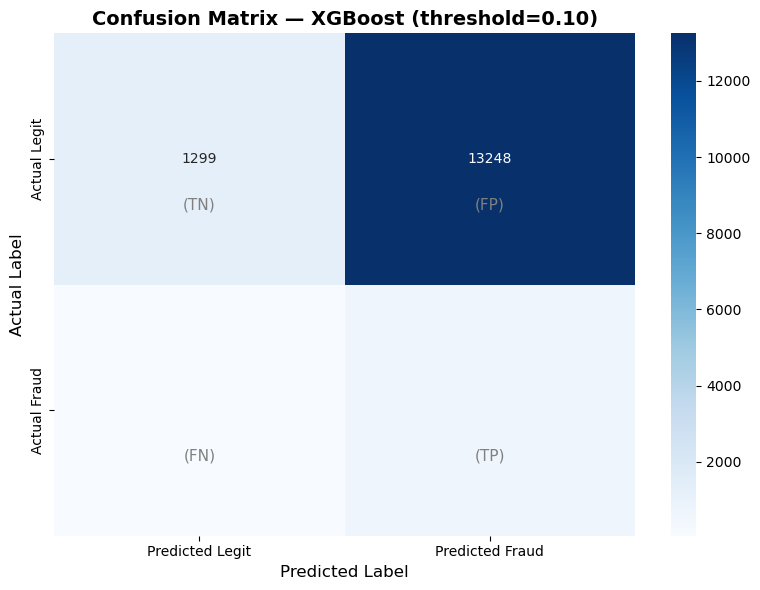

✅ Confusion matrix plotted!


In [23]:
# ============================================
# FINAL EVALUATION METRICS + CONFUSION MATRIX
# ============================================

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Final predictions at threshold 0.10
y_final_pred   = (y_pred_proba >= 0.10).astype(int)

# ── CONFUSION MATRIX ──
cm             = confusion_matrix(y_test, y_final_pred)
tn, fp, fn, tp = cm.ravel()

# ── METRICS ──
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2*(precision*recall)/(precision+recall)

# ── PRINT METRICS ──
print("="*50)
print("   FINAL MODEL EVALUATION — XGBoost")
print("="*50)
print(f"\n   Threshold  : 0.10")
print(f"   {'─'*40}")
print(f"   Accuracy   : {accuracy*100:.2f}%")
print(f"   Precision  : {precision*100:.2f}%")
print(f"   Recall     : {recall*100:.2f}%  ← Most Important!")
print(f"   F1 Score   : {f1:.2f}")
print(f"   {'─'*40}")
print(f"   TP : {tp:>6}  → Frauds caught   ✅")
print(f"   FP : {fp:>6}  → False alarms    ⚠️")
print(f"   FN : {fn:>6}  → Frauds missed   ❌")
print(f"   TN : {tn:>6}  → Legit correct   ✅")
print(f"   {'─'*40}")
print(f"   Total fraud    : {tp+fn}")
print(f"   Fraud caught   : {tp} ({recall*100:.1f}%) ✅")
print(f"   Fraud missed   : {fn} ({(fn/(tp+fn))*100:.1f}%) ❌")
print("="*50)

# ── CLASSIFICATION REPORT ──
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    y_final_pred,
    target_names=['Legitimate', 'Fraud']
))

# ── CONFUSION MATRIX VISUAL ──
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= ['Predicted Legit', 'Predicted Fraud'],
    yticklabels= ['Actual Legit',    'Actual Fraud']
)
plt.title('Confusion Matrix — XGBoost (threshold=0.10)',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Add labels inside boxes
for i in range(2):
    for j in range(2):
        label = ['TN', 'FP', 'FN', 'TP'][i*2+j]
        plt.text(
            j+0.5, i+0.7,
            f'({label})',
            ha         = 'center',
            fontsize   = 11,
            color      = 'gray'
        )

plt.tight_layout()
plt.show()
print("✅ Confusion matrix plotted!")

In [27]:
# ============================================
# STACKING MODEL - COMPLETELY FIXED
# ============================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1 → Scale data ──
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── STEP 2 → Base models ──
# NO class weights on any base model!
base_models = [
    ('logistic',
     LogisticRegression(
         max_iter     = 5000,
         random_state = 42,
         solver       = 'saga'
     )),
    ('random_forest',
     RandomForestClassifier(
         n_estimators = 100,
         random_state = 42
     )),
    ('xgboost',
     xgb.XGBClassifier(
         n_estimators     = 200,
         max_depth        = 6,
         learning_rate    = 0.1,
         scale_pos_weight = scale_pos_weight,
         random_state     = 42,
         eval_metric      = 'logloss'
     ))
]

# ── STEP 3 → Meta model ──
# NO class weight here!
# Let threshold handle imbalance!
meta_model = LogisticRegression(
    max_iter     = 5000,
    random_state = 42,
    solver       = 'saga'
)

# ── STEP 4 → Build stacking ──
stacking_model = StackingClassifier(
    estimators      = base_models,
    final_estimator = meta_model,
    cv              = 5,
    passthrough     = False
)

# ── STEP 5 → Train ──
print("Training Stacking model...")
print("Please wait...")
stacking_model.fit(X_train_scaled, y_train)
print("Stacking model trained!")

# ── STEP 6 → Test multiple thresholds ──
y_pred_stack_proba = stacking_model.predict_proba(
    X_test_scaled)[:, 1]

print("\n=== STACKING THRESHOLD COMPARISON ===")
print(f"{'Threshold':<12}{'TP':<8}{'FP':<8}"
      f"{'FN':<8}{'Recall':<10}{'Precision'}")
print("-"*55)

best_recall    = 0
best_threshold = 0
best_tp        = 0
best_fn        = 0

for threshold in [0.05, 0.10, 0.15,
                  0.20, 0.30, 0.50]:
    y_pred_t       = (y_pred_stack_proba
                      >= threshold).astype(int)
    cm             = confusion_matrix(
        y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    recall         = tp/(tp+fn) if (tp+fn)>0 else 0
    precision      = tp/(tp+fp) if (tp+fp)>0 else 0

    if recall > best_recall:
        best_recall    = recall
        best_threshold = threshold
        best_tp        = tp
        best_fn        = fn

    print(f"{threshold:<12}{tp:<8}{fp:<8}"
          f"{fn:<8}{recall*100:.1f}%{'':<6}"
          f"{precision*100:.1f}%")

print(f"\nBest threshold : {best_threshold}")
print(f"Best recall    : {best_recall*100:.2f}%")

# ── STEP 7 → Final comparison ──
print("\n=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<25}{'Recall':<10}{'TP':<8}{'FN'}")
print("-"*50)
print(f"{'Logistic Regression':<25}"
      f"{'55%':<10}{'414':<8}{'339'}")
print(f"{'Random Forest':<25}"
      f"{'3%':<10}{'22':<8}{'731'}")
print(f"{'XGBoost':<25}"
      f"{'92%':<10}{'691':<8}{'62'}")
print(f"{'Stacking':<25}"
      f"{best_recall*100:.0f}%{'':<7}"
      f"{best_tp:<8}{best_fn}")

Training Stacking model...
Please wait...
Stacking model trained!

=== STACKING THRESHOLD COMPARISON ===
Threshold   TP      FP      FN      Recall    Precision
-------------------------------------------------------
0.05        254     4874    499     33.7%      5.0%
0.1         24      17      729     3.2%      58.5%
0.15        23      1       730     3.1%      95.8%
0.2         22      0       731     2.9%      100.0%
0.3         18      0       735     2.4%      100.0%
0.5         0       0       753     0.0%      0.0%

Best threshold : 0.05
Best recall    : 33.73%

=== FINAL MODEL COMPARISON ===
Model                    Recall    TP      FN
--------------------------------------------------
Logistic Regression      55%       414     339
Random Forest            3%        22      731
XGBoost                  92%       691     62
Stacking                 34%       254     499


In [1]:
import os
print("Files in project folder:")
for f in os.listdir():
    print(f"→ {f}")

Files in project folder:
→ -1.14-windows.xml
→ .anaconda
→ .codex
→ .conda
→ .condarc
→ .continuum
→ .ipynb_checkpoints
→ .ipython
→ .junie
→ .jupyter
→ .matplotlib
→ .MCTranscodingSDK
→ anaconda3
→ AppData
→ Application Data
→ Contacts
→ Cookies
→ Documents
→ Downloads
→ Favorites
→ FD.ipynb
→ Lightworks
→ Links
→ Local Settings
→ Music
→ My Documents
→ NetHood
→ ntuser.dat
→ ntuser.dat.log1
→ ntuser.dat.log2
→ NTUSER.DAT{2c01e907-d02d-11ee-a957-b48c9d35f0c4}.TM.blf
→ NTUSER.DAT{2c01e907-d02d-11ee-a957-b48c9d35f0c4}.TMContainer00000000000000000001.regtrans-ms
→ NTUSER.DAT{2c01e907-d02d-11ee-a957-b48c9d35f0c4}.TMContainer00000000000000000002.regtrans-ms
→ ntuser.dat{fad849d7-09e6-11ef-a967-b48c9d35f0c4}.TxR.0.regtrans-ms
→ ntuser.dat{fad849d7-09e6-11ef-a967-b48c9d35f0c4}.TxR.1.regtrans-ms
→ ntuser.dat{fad849d7-09e6-11ef-a967-b48c9d35f0c4}.TxR.2.regtrans-ms
→ ntuser.dat{fad849d7-09e6-11ef-a967-b48c9d35f0c4}.TxR.blf
→ ntuser.dat{fad849d8-09e6-11ef-a967-b48c9d35f0c4}.TM.blf
→ ntuser.dat{f

SAVING FILE

In [26]:
import os
import joblib

# Check current working directory
print(f"Current folder: {os.getcwd()}")

# Save model to correct project folder
save_path = r"C:\Users\Asus\Downloads\Project"

joblib.dump(xgb_model,
            f"{save_path}\\training.pkl")

print(f"✅ Model saved to: {save_path}")

# Verify files saved
print("\nFiles in project folder:")
for f in os.listdir(save_path):
    print(f"→ {f}")

Current folder: C:\Users\Asus
✅ Model saved to: C:\Users\Asus\Downloads\Project

Files in project folder:
→ confusion_matrix.png
→ creditcard_2023.csv
→ customer_report.txt
→ feature_importance.json
→ FraudDetectionDataset.csv
→ fraud_detection_model.pkl
→ fraud_result.json
→ label_encoder.pkl
→ le_device.pkl
→ le_location.pkl
→ le_payment.pkl
→ le_transaction.pkl
→ prediction.pkl
→ training.pkl
→ xgb_model_v2.pkl


In [27]:
# Check if separate encoders exist
try:
    print(le_transaction.classes_)
    print("✅ Separate encoders exist!")
    print("Run save code above!")
except:
    print("❌ Separate encoders NOT found!")
    print("Phase 1 uses ONE encoder!")
    print("Encoders already saved from Phase 2!")
    print("No need to run save code!")

❌ Separate encoders NOT found!
Phase 1 uses ONE encoder!
Encoders already saved from Phase 2!
No need to run save code!
